# Traffic Accident Analysis in Jordan Using SQL

## Overview

This notebook analyzes traffic accident data in Jordan using SQL queries to uncover trends, patterns, and key insights. The analysis focuses on understanding accident distribution across different locations, time periods, environmental conditions, and other contributing factors.


In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read CSV
df = pd.read_csv("E:\D\Jordan Traffic Accident\Data\Cleaned\JO_traffic_accidents_raw_data_En.csv")

# Create SQLite database
conn = sqlite3.connect("accidents.db")

# Save dataframe as a table
df.to_sql("accidents", conn, if_exists="replace", index=False)

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
C:\Users\ahmad\AppData\Local\Temp\ipykernel_28656\1974506701.py:7: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("E:\D\Jordan Traffic Accident\Data\Cleaned\JO_traffic_accidents_raw_data_En.csv")


70715

In [2]:
pd.read_sql_query("""
PRAGMA table_info(accidents)
""", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,Accident Type,TEXT,0,None,0
1,1,Date,TEXT,0,None,0
2,2,Speed (Km),INTEGER,0,None,0
3,3,Simple Injuries,INTEGER,0,None,0
4,4,Severe Injuries,INTEGER,0,None,0
5,5,Death,INTEGER,0,None,0
6,6,Medium Injuries,INTEGER,0,None,0
7,7,Road Lanes,TEXT,0,None,0
8,8,Road Surfuce Description,TEXT,0,None,0
9,9,Vehicle Country,TEXT,0,None,0


## 1- Which cities have the highest rate of severe injuries and deaths from traffic accidents?

In [3]:
query = """
SELECT City,
    COUNT(*) AS Number_of_Accidents,
    ROUND(
        SUM(
            CASE
                WHEN "Severe Injuries" >= 1 OR "Death" >= 1 THEN 1 ELSE 0
            END
        ) * 100.0 / COUNT(*), 2
    ) AS Percentage_of_Fatal_Accidents
FROM (
    SELECT City,
           Date,
           MAX("Severe Injuries") AS "Severe Injuries",
           MAX("Death")           AS Death
    FROM accidents
    GROUP BY City, Date
) AS deduplicated
GROUP BY City
ORDER BY Percentage_of_Fatal_Accidents DESC
"""

results = pd.read_sql_query(query, conn)
results

,City,Number_of_Accidents,Percentage_of_Fatal_Accidents
0,Maan,201,7.46
1,Mafraq,566,6.71
2,Tafila,165,4.85
3,Ajloun,276,3.26
4,Jerash,519,2.89
5,al-karak,438,2.74
6,Aqaba,612,2.45
7,Madaba,472,1.48
8,Balqa,1539,1.43
9,Zarqa,2693,1.11


Maan (7.46%) and Mafraq (6.71%) record the highest rates of severe injuries and fatalities among all governorates, followed by Tafila (4.85%) and Ajloun (3.26%), indicating that accidents in these areas are more likely to result in serious outcomes.

In contrast, Amman, despite reporting the largest number of accidents (21,360 cases), has the lowest severe injury and fatality rate (0.37%), suggesting lower accident severity compared with less urbanized regions.

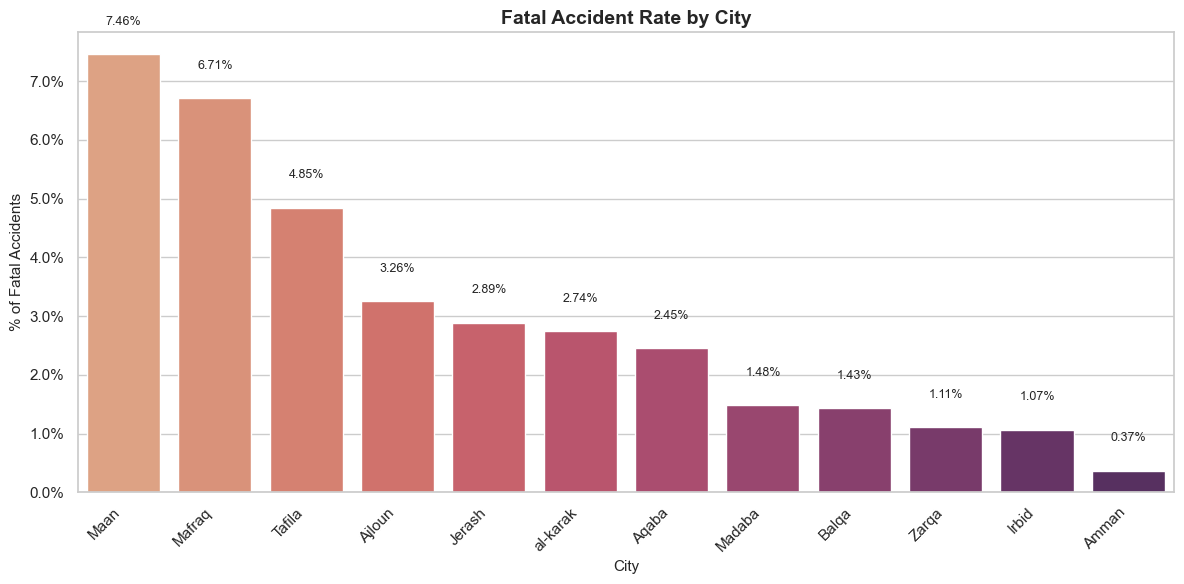

In [4]:
import matplotlib.ticker as mtick

# Fatal accident rate by city — bars sorted DESC, labeled with %
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=results, x="City", y="Percentage_of_Fatal_Accidents", hue="City", palette="flare", order=results["City"], legend=False)

for i, row in results.iterrows():
    ax.text(i, row["Percentage_of_Fatal_Accidents"] + 0.5, f"{row['Percentage_of_Fatal_Accidents']}%", ha="center", fontsize=9)

ax.set_title("Fatal Accident Rate by City", fontsize=14, fontweight="bold")
ax.set_xlabel("City", fontsize=11)
ax.set_ylabel("% of Fatal Accidents", fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 2- What driver mistakes are most frequently associated with severe injuries or fatalities?

In [5]:
query = """
SELECT "Driver Mistake",
    COUNT(*) AS Number_of_Accidents,
    ROUND(
        SUM(
            CASE
                WHEN "Severe Injuries" >= 1 OR "Death" >= 1 THEN 1 ELSE 0
            END
        ) * 100.0 / COUNT(*), 2
    ) AS Percentage_of_High_Risk_Accidents_per_Mistake
FROM (
    SELECT "Driver Mistake",
           Date,
           MAX("Severe Injuries") AS "Severe Injuries",
           MAX("Death")           AS Death
    FROM accidents
    GROUP BY "Driver Mistake", Date
) AS deduplicated
GROUP BY "Driver Mistake"
ORDER BY Percentage_of_High_Risk_Accidents_per_Mistake DESC, Number_of_Accidents DESC
LIMIT 20
"""

results = pd.read_sql_query(query, conn)
results

,Driver Mistake,Number_of_Accidents,Percentage_of_High_Risk_Accidents_per_Mistake
0,Operating without a License,2,50.00
1,Speeding 30-50km/h,9,11.11
2,Improper Overtaking,23,8.70
3,Sharp curved,371,6.74
4,Wrong way driving,75,4.00
5,Speeding up to 20km/h more than speed limit,26,3.85
6,Loss of control,288,2.43
7,Stopping in the lane and blocking traffic,42,2.38
8,Violating no pass sign,55,1.82
9,Improper lane changes,6190,1.68


Operating without a license (50%), speeding 30–50 km/h above the speed limit (11.11%), and improper overtaking (8.70%) are the driver mistakes most strongly associated with severe injuries and fatalities, indicating that high-risk driving behaviors significantly increase accident severity.

Although violation of traffic rules (26,495 accidents), tailgating (8,518), and neglecting traffic safety precautions (7,210) are the most common causes of accidents, their lower severe-injury/fatality rates suggest they contribute more to accident frequency than to the likelihood of serious outcomes.

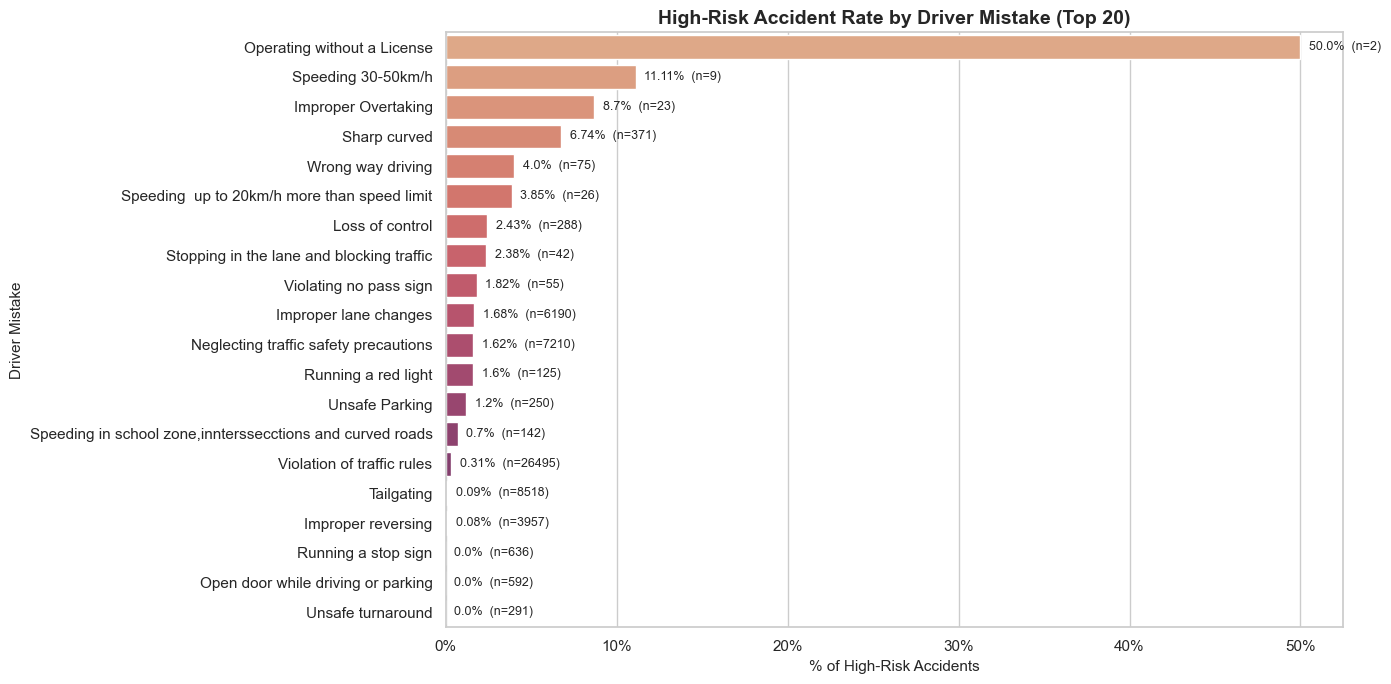

In [6]:
# Top 20 driver mistakes by high-risk accident rate, sized by total count
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=results, x="Percentage_of_High_Risk_Accidents_per_Mistake", y="Driver Mistake", hue="Driver Mistake", palette="flare", order=results["Driver Mistake"], legend=False)

for i, row in results.iterrows():
    ax.text(row["Percentage_of_High_Risk_Accidents_per_Mistake"] + 0.5, i, f"{row['Percentage_of_High_Risk_Accidents_per_Mistake']}%  (n={row['Number_of_Accidents']})", va="center", fontsize=9)

ax.set_title("High-Risk Accident Rate by Driver Mistake (Top 20)", fontsize=14, fontweight="bold")
ax.set_xlabel("% of High-Risk Accidents", fontsize=11)
ax.set_ylabel("Driver Mistake", fontsize=11)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

## 3- What is the average number of vehicles involved per accident, and does it rise with speed?

In [7]:
query = """
SELECT "Number of Cars",
    COUNT(*) AS Number_of_Accidents,
    ROUND(AVG("Speed (Km)"), 2) AS SPEED
FROM (
    SELECT "Number of Cars",
           Date,
           MAX("Speed (Km)") AS "Speed (Km)"
    FROM accidents
    GROUP BY "Number of Cars", Date
) AS deduplicated
GROUP BY "Number of Cars"
ORDER BY Number_of_Accidents DESC
"""

results = pd.read_sql_query(query, conn)
results

,Number of Cars,Number_of_Accidents,SPEED
0,2,25259,50.80
1,1,3642,50.60
2,3,1853,52.56
3,4,282,53.55
4,5,32,58.44
5,6,8,58.75
6,7,4,62.50
7,9,1,30.00
8,8,1,60.00


The average severe-injury or fatal accident involves approximately 2.1 vehicles, with two-vehicle crashes accounting for the majority of cases (25,259 accidents). Accidents involving five or more vehicles are relatively uncommon but represent more complex collision events.

A clear upward trend is observed between vehicle count and average speed, increasing from about 50.6 km/h in single-vehicle accidents to over 58–62 km/h in crashes involving five to seven vehicles, suggesting that higher speeds may increase the likelihood of multi-vehicle severe accidents.

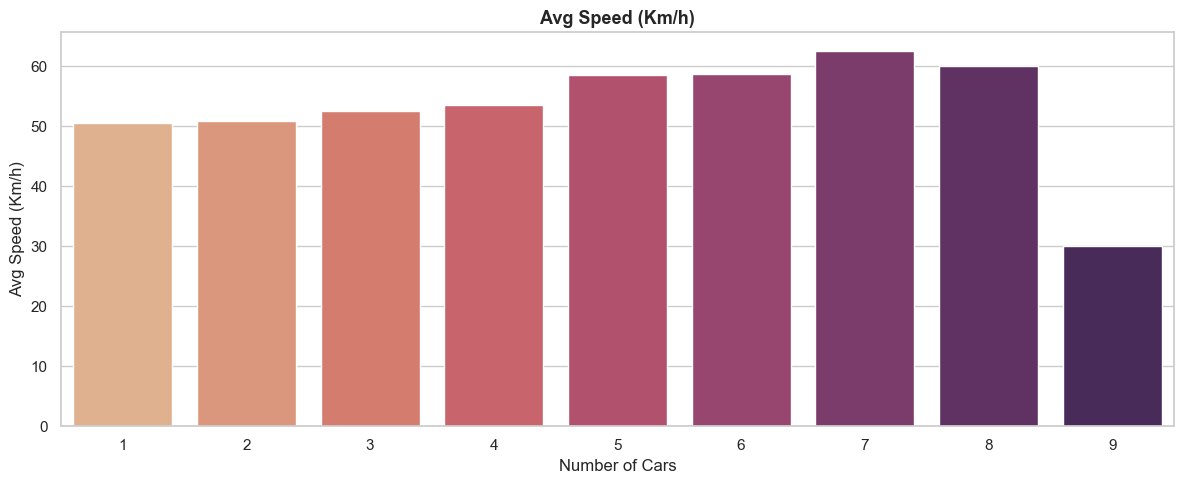

In [8]:
# Accident count by number of cars involved
fig, axes = plt.subplots(1, 1, figsize=(12, 5))
sns.set_theme(style="whitegrid")

sns.barplot(data=results, x="Number of Cars", y="SPEED", hue="Number of Cars", palette="flare", legend=False, ax=axes)
axes.set_title("Avg Speed (Km/h)", fontsize=13, fontweight="bold")
axes.set_xlabel("Number of Cars")
axes.set_ylabel("Avg Speed (Km/h)")

plt.tight_layout()
plt.show()

## 4- When (by month, season, or day of week) do the most severe accidents occur?

In [9]:
query = """
SELECT CAST(SUBSTR(Date, 1, INSTR(Date, '/') - 1) AS INTEGER) AS Month,
    COUNT(*) AS Number_of_Accidents,
    ROUND(SUM(CASE WHEN "Severe Injuries" >= 1 OR "Death" >= 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS Pct_Severe
FROM (
    SELECT Date, MAX("Severe Injuries") AS "Severe Injuries", MAX("Death") AS Death
    FROM accidents
    GROUP BY Date
)
GROUP BY Month
ORDER BY Month
"""
month_df = pd.read_sql_query(query, conn)
month_df["Month"] = pd.to_datetime(month_df["Month"], format="%m").dt.strftime("%b")
month_df

,Month,Number_of_Accidents,Pct_Severe
0,Jan,6631,1.04
1,Feb,1043,0.96
2,Mar,1043,1.34
3,Apr,1045,0.86
4,May,969,0.93
5,Jun,6904,0.90
6,Jul,923,0.76
7,Aug,861,0.70
8,Sep,6886,0.93
9,Oct,1047,1.05


Severe accidents are most likely to occur in November (1.47%), March (1.34%), and December (1.30%), indicating that accidents during these months have a higher probability of resulting in severe injuries or fatalities.

In terms of accident volume, September (6,886 accidents), June (6,904), and January (6,631) recorded the highest number of accidents, but their severity rates remain below the peak levels observed in November and March, suggesting that accident frequency and accident severity do not necessarily follow the same

In [10]:
query = """
SELECT Date,
    MAX("Severe Injuries") AS "Severe Injuries",
    MAX("Death") AS Death
FROM accidents
GROUP BY Date
"""
dow_df = pd.read_sql_query(query, conn)

dow_df["Date"] = pd.to_datetime(dow_df["Date"], format="%m/%d/%y %I:%M %p")
dow_df["DayNum"] = dow_df["Date"].dt.dayofweek  # Monday=0, Sunday=6
dow_df = dow_df.groupby("DayNum").agg(
    Number_of_Accidents=("Date", "count"),
    Pct_Severe=("Severe Injuries", lambda x: round((((x >= 1) | (dow_df.loc[x.index, "Death"] >= 1)).sum() * 100.0) / len(x), 2))
).reset_index()

dow_df["Day"] = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_df

,DayNum,Number_of_Accidents,Pct_Severe,Day
0,0,3580,1.01,Mon
1,1,4281,0.70,Tue
2,2,3767,0.82,Wed
3,3,5054,1.03,Thu
4,4,3915,1.33,Fri
5,5,4187,1.27,Sat
6,6,4593,0.76,Sun


By day of the week, Friday (1.33%) and Saturday (1.27%) have the highest rates of severe accidents, suggesting that crashes occurring during the weekend are more likely to result in serious injuries or fatalities.

While Thursday records the highest number of accidents (5,054) and Sunday follows with 4,593, their lower severity rates indicate that accident frequency is not the primary driver of accident severity, which appears to increase during weekend travel periods.

In [11]:
query = """
SELECT 
    CASE 
        WHEN CAST(SUBSTR(Date, 1, INSTR(Date, '/') - 1) AS INTEGER) IN (12, 1, 2) THEN 'Winter'
        WHEN CAST(SUBSTR(Date, 1, INSTR(Date, '/') - 1) AS INTEGER) IN (3, 4, 5)  THEN 'Spring'
        WHEN CAST(SUBSTR(Date, 1, INSTR(Date, '/') - 1) AS INTEGER) IN (6, 7, 8)  THEN 'Summer'
        ELSE 'Fall'
    END AS Season,
    COUNT(*) AS Number_of_Accidents,
    ROUND(SUM(CASE WHEN "Severe Injuries" >= 1 OR "Death" >= 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS Pct_Severe
FROM (
    SELECT Date, MAX("Severe Injuries") AS "Severe Injuries", MAX("Death") AS Death
    FROM accidents
    GROUP BY Date
)
GROUP BY Season
ORDER BY Number_of_Accidents DESC
"""
season_df = pd.read_sql_query(query, conn)
season_df

,Season,Number_of_Accidents,Pct_Severe
0,Fall,8955,1.01
1,Summer,8688,0.86
2,Winter,8677,1.06
3,Spring,3057,1.05


Winter (1.06%) and Spring (1.05%) record the highest proportions of severe accidents, closely followed by Fall (1.01%), indicating that accidents during these seasons are slightly more likely to result in severe injuries or fatalities.

Although Fall has the highest accident volume (8,955 accidents), its severity rate is comparable to Winter and Spring, while Summer shows the lowest severity rate (0.86%), suggesting relatively safer driving conditions during that season.

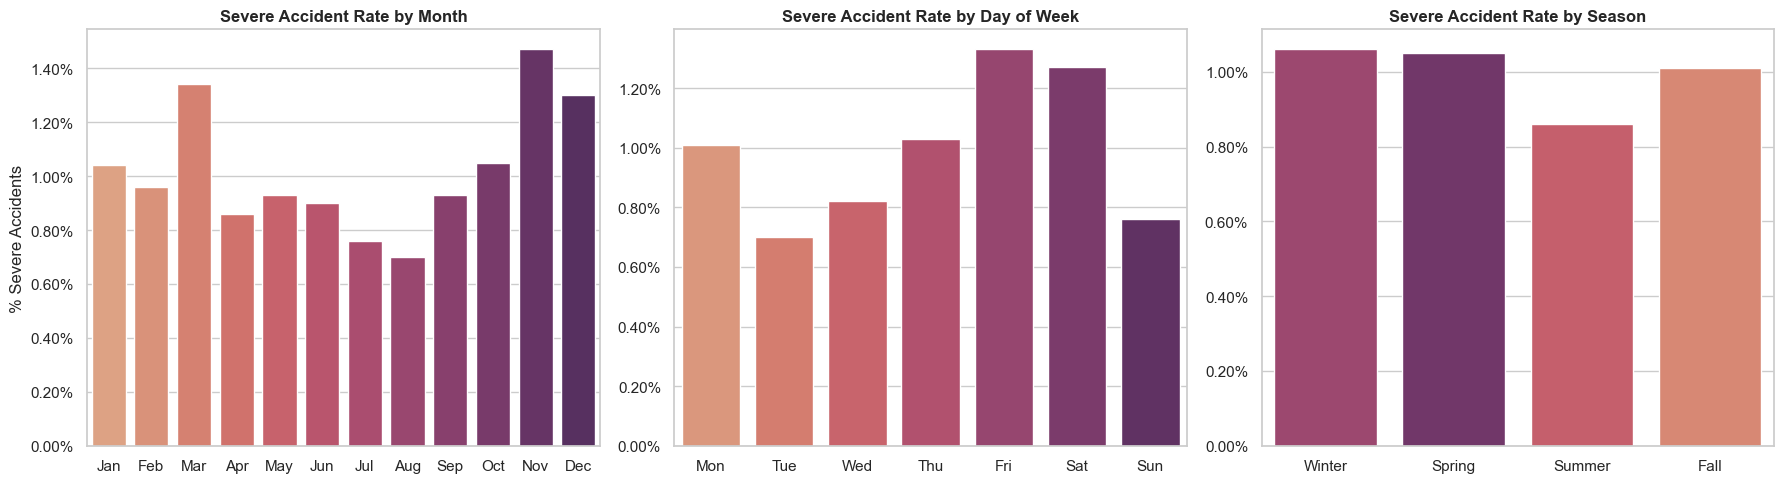

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

sns.barplot(data=month_df, x="Month", y="Pct_Severe", hue="Month", palette="flare", legend=False, ax=axes[0])
axes[0].set_title("Severe Accident Rate by Month", fontweight="bold")
axes[0].set_ylabel("% Severe Accidents")
axes[0].set_xlabel("")

sns.barplot(data=dow_df, x="Day", y="Pct_Severe", hue="Day", palette="flare", legend=False, ax=axes[1])
axes[1].set_title("Severe Accident Rate by Day of Week", fontweight="bold")
axes[1].set_ylabel("")
axes[1].set_xlabel("")

season_order = ["Winter", "Spring", "Summer", "Fall"]
sns.barplot(data=season_df, x="Season", y="Pct_Severe", hue="Season", palette="flare", legend=False, order=season_order, ax=axes[2])
axes[2].set_title("Severe Accident Rate by Season", fontweight="bold")
axes[2].set_ylabel("")
axes[2].set_xlabel("")

for ax in axes:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()